In [1]:
import pandas as pd
import numpy as np

ufos = pd.read_csv('./data/ufos.csv')
ufos.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700.0,45 minutes,This event took place in early fall around 194...,4/27/2004,29.883056,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200.0,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.384210,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20.0,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.200000,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20.0,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.978333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900.0,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.418056,-157.803611


In [2]:
ufos.isnull().sum()


datetime                   0
city                       0
state                   5797
country                 9670
shape                   1932
duration (seconds)         0
duration (hours/min)       0
comments                  15
date posted                0
latitude                   0
longitude                  0
dtype: int64

### Convert the ufos data to a small dataframe with fresh titles. Check the unique values in the Country field.

In [3]:
ufos = pd.DataFrame({'Seconds': ufos['duration (seconds)'], 'Country': ufos['country'],'Latitude': ufos['latitude'],'Longitude': ufos['longitude']})



In [4]:

ufos.Country.unique()

array(['us', nan, 'gb', 'ca', 'au', 'de'], dtype=object)

### Now, you can reduce the amount of data we need to deal with by dropping any null values and only importing sightings between 1-60 seconds:

In [6]:
ufos.dropna(inplace=True)

ufos = ufos[(ufos['Seconds'] >= 1) & (ufos['Seconds'] <= 60)]

ufos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29360 entries, 2 to 80330
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Seconds    29360 non-null  float64
 1   Country    29360 non-null  int64  
 2   Latitude   29360 non-null  float64
 3   Longitude  29360 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 1.1 MB


### Import Scikit-learn's LabelEncoder library to convert the text values for countries to a number:

In [7]:
from sklearn.preprocessing import LabelEncoder

ufos['Country'] = LabelEncoder().fit_transform(ufos['Country'])

ufos.head()

,Seconds,Country,Latitude,Longitude
2,20.0,3,53.200000,-2.916667
3,20.0,4,28.978333,-96.645833
14,30.0,4,35.823889,-80.253611
18,20.0,5,32.364167,-64.678611
23,60.0,4,45.582778,-122.352222


## Building Model


In [9]:
from sklearn.model_selection import train_test_split

Selected_features = ['Seconds', 'Latitude', 'Longitude']

X = ufos[Selected_features]
y = ufos['Country']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 0)


## Logistic Regression


In [10]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(classification_report(y_test, predictions))
print("Predicted labels:", predictions)
print("Accuracy: ", accuracy_score(y_test, predictions))


              precision    recall  f1-score   support

           0       0.76      1.00      0.87        45
           1       0.00      0.00      0.00       238
           2       0.00      0.00      0.00        12
           3       0.54      0.70      0.61       139
           4       0.87      1.00      0.93      4739
           5       0.77      0.20      0.32       699

    accuracy                           0.86      5872
   macro avg       0.49      0.48      0.45      5872
weighted avg       0.81      0.86      0.81      5872

Predicted labels: [4 4 4 ... 4 4 4]
Accuracy:  0.8552452316076294


c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\

In [11]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[  45,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,  238,    0],
       [   0,    0,    0,   10,    0,    2],
       [   0,    0,    2,   97,    0,   40],
       [   0,    0,    0,    0, 4739,    0],
       [  14,    0,    4,   74,  466,  141]])

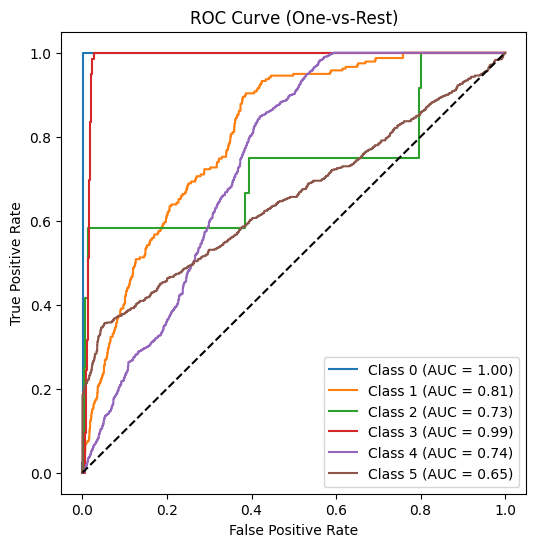

In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import label_binarize

# Binarize the output
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_scores = model.predict_proba(X_test)

fig = plt.figure(figsize=(6, 6))
for i in range(len(classes)):
	fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
	plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc_score(y_test_bin[:, i], y_scores[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest)')
plt.legend()
plt.show()

In [17]:
import pickle
model_filename = 'ufo-model.pkl'
pickle.dump(model, open(model_filename,'wb'))

model = pickle.load(open('ufo-model.pkl','rb'))
print(model.predict([[50,44,-12]]))

[5]


c:\Users\Nkansah\ML-For-Beginners\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
